In [1]:
INDIA_PROJECTED_CRS = "24378"

In [2]:
BACKGROUND_COLOR = "lightgreen"
BUILDING_COLOR = "yellow"
SETTLEMENT_COLOR = "darkred"
WATER_COLOR = "C0"
CROPLAND_COLOR = "goldenrod"
SLOPE_COLOR = "grey"

# Setup

In [3]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely import MultiPolygon

In [5]:
from gridsample.utils import create_ids, save_shapefiles
from gridsample.utils_rooftop import generate_colormap
# from gridsample.mapping.plot import create_interactive_map

In [6]:
def clean_geometry(gdf):
    """Clean geometry collections and multipolygons by keeping only polygon geometries."""
    def _clean_geom(geom):
        if geom is None:
            return None
        
        # If it's already a Polygon, return as is
        if geom.geom_type == 'Polygon':
            return geom

        # Get polygons from MultiPolygon or GeometryCollection 
        polygons = []
        if hasattr(geom, 'geoms'):
            for g in geom.geoms:
                if g.geom_type == 'Polygon':
                    polygons.append(g)

        # Return appropriate geometry based on number of polygons found
        if not polygons:
            return None
        if len(polygons) == 1:
            return polygons[0]
        return MultiPolygon(polygons)

    # Apply cleaning and drop invalid geometries
    gdf = gdf.copy()
    gdf.geometry = gdf.geometry.apply(_clean_geom)
    return gdf.dropna(subset=['geometry'])

In [7]:
LOCATION = "Barwani"

In [8]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "01 Processed Data"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "02 Outputs" / "v1"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## Load cleaned khasras

In [9]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
DISTRICT_MAPS_OUTPUT_DATA_DIR = OUTPUT_DATA_DIR / "District Maps"
DISTRICT_MAPS_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
barwani_gdf = gpd.read_parquet(PROCESSED_DATA_DIR / "Cleaned Khasras" / "barwani_cleaned_khasras.parquet")
barwani_gdf

,Khasra ID,Khasra Name,Patch Name,geometry
1283,BWI20_khasra_61,61,BWI20,"POLYGON ((75.31456 21.39287, 75.31459 21.39299..."
1285,BWI20_khasra_62,62,BWI20,"POLYGON ((75.31456 21.39287, 75.31446 21.39290..."
1287,BWI20_khasra_57,57,BWI20,"POLYGON ((75.31134 21.39444, 75.31118 21.39443..."
1289,BWI32_khasra_50,50,BWI32,"POLYGON ((75.30451 21.39008, 75.30577 21.39097..."
1291,BWI32_khasra_48,48,BWI32,"POLYGON ((75.30416 21.39163, 75.30413 21.39163..."
...,...,...,...,...
32755,BWI3935_khasra_79/2_part_4,79/2,BWI3935,"POLYGON ((74.95441 22.01890, 74.95442 22.01897..."
32757,BWI3935_khasra_38_part_4,38,BWI3935,"POLYGON ((74.95441 22.01890, 74.95442 22.01897..."
32759,BWI3983_khasra_162_part_10,162,BWI3983,"POLYGON ((75.08386 22.00594, 75.08385 22.00594..."
32761,BWI3983_khasra_120_part_5,120,BWI3983,"POLYGON ((75.08386 22.00594, 75.08385 22.00594..."


In [18]:
barwani_gdf[barwani_gdf.duplicated(subset=["Khasra Name", "Patch Name"], keep=False)].sort_values(by="Khasra ID")

,Khasra ID,Khasra Name,Patch Name,geometry
3125,BWI1004_khasra_121/1_part_1,121/1,BWI1004,"POLYGON ((74.94467 21.72595, 74.94464 21.72608..."
3127,BWI1004_khasra_121/1_part_2,121/1,BWI1004,"POLYGON ((74.94475 21.72560, 74.94469 21.72559..."
3165,BWI1004_khasra_123_part_1,123,BWI1004,"POLYGON ((74.94874 21.72558, 74.94866 21.72557..."
27003,BWI1004_khasra_123_part_2,123,BWI1004,"POLYGON ((74.94871 21.72512, 74.94872 21.72532..."
27019,BWI1004_khasra_123_part_3,123,BWI1004,"POLYGON ((74.94844 21.72474, 74.94840 21.72474..."
...,...,...,...,...
3097,BWI995_khasra_294_part_2,294,BWI995,"POLYGON ((74.94081 21.72161, 74.94083 21.72167..."
3111,BWI995_khasra_343_part_1,343,BWI995,"POLYGON ((74.93960 21.71570, 74.93959 21.71572..."
3113,BWI995_khasra_343_part_2,343,BWI995,"POLYGON ((74.93911 21.71535, 74.93920 21.71539..."
26969,BWI995_khasra_343_part_3,343,BWI995,"POLYGON ((74.93920 21.71539, 74.93921 21.71539..."


In [19]:
gdf_4326 = barwani_gdf
gdf = barwani_gdf.to_crs(INDIA_PROJECTED_CRS)

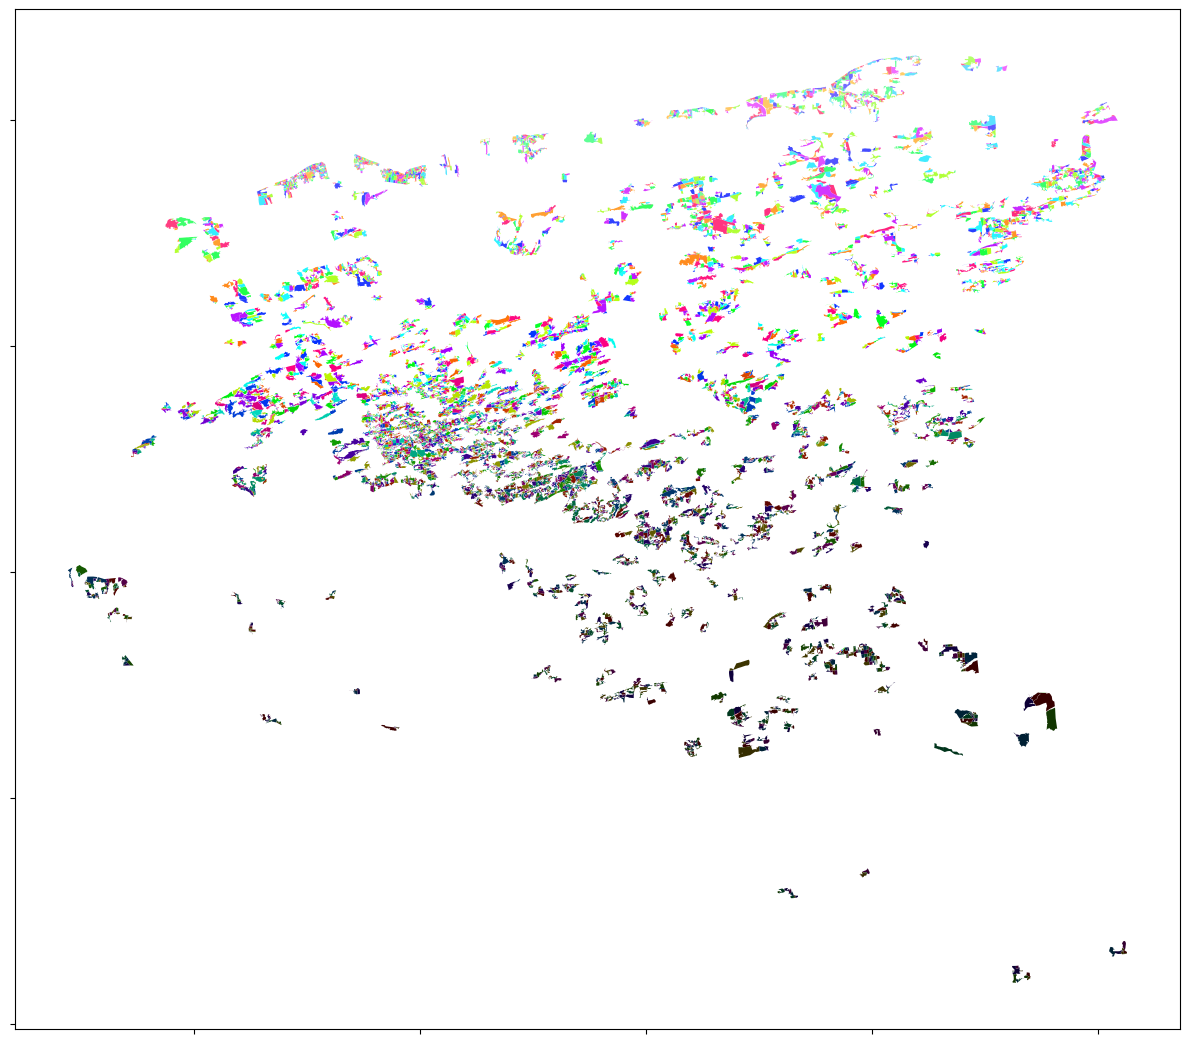

In [20]:
ax = gdf.plot(
    cmap=ListedColormap(generate_colormap(len(gdf))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras.png",
    dpi=300,
    bbox_inches="tight",
)

In [21]:
save_shapefiles(
    gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_initial",
    formats=["parquet", "kml", "csv"],
)

## Unusable layers

Overlap layers and decide which to discard and which to take forward

### Buildings

In [22]:
from gridsample.utils_rooftop import (
    get_overlapping_s2_cell_ids,
    get_s2_cell_polygons,
    download_VIDA_rooftops_data_by_s2,
    get_matched_rooftop_centroids_from_s2_file,
)

#### Identify S2 cell IDs

In [23]:
s2_cell_ids = get_overlapping_s2_cell_ids(gdf_4326)
print("Number of unique S2 cell IDs that overlap these shapes:", len(s2_cell_ids))
print("Unique S2 cell IDs:", s2_cell_ids)

/Users/amiremami/IDinsight Repos/gridsample/gridsample/utils_rooftop.py:125: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 1: 0
Number of unique S2 cell IDs that overlap these shapes: 4
Unique S2 cell IDs: [4312478118183960576, 4314166968044224512, 4134585932902825984, 4135148882856247296]


#### Check if identified cells cover all areas of interest


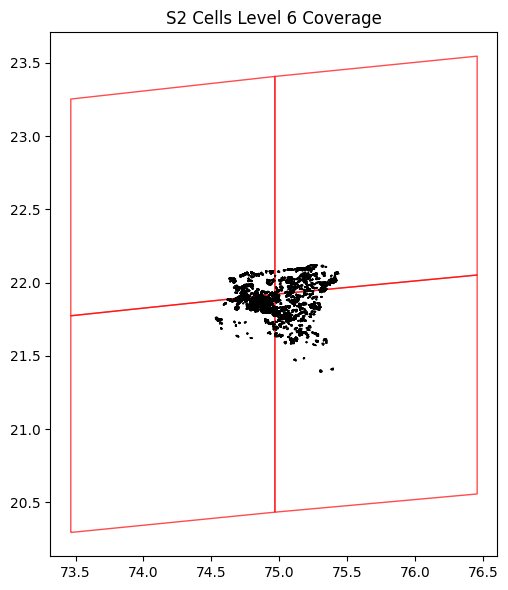

0.0 square degrees area not covered by an S2 cell


In [24]:
s2_cells_gdf = get_s2_cell_polygons(s2_cell_ids)

# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_4326.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf_4326.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")


In [25]:
#### Download the S2 cells
download_VIDA_rooftops_data_by_s2(
    s2_cell_ids=s2_cell_ids,
    country_iso_code="IND",
    target_data_dir=RAW_DATA_DIR / "rooftops",
)

File 4312478118183960576 already exists.
File 4314166968044224512 already exists.
File 4134585932902825984 already exists.
File 4135148882856247296 already exists.


#### Load and process rooftop data

In [ ]:
try:
    print("Checking for existing filtered rooftops...")
    subset_rooftops_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Rooftops" / "rooftops.parquet"
    )
except FileNotFoundError:
    print("No saved filtered rooftops found, processing raw data...")
    rooftop_gdf_list = []
    for s2_cell_id in s2_cell_ids:
        s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
        rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
        rooftop_gdf_list.append(rooftop_gdf)

    rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
    rooftop_gdf = rooftop_gdf[
        [
            "bf_source",
            "confidence",
            "area_in_meters",
            "geometry",
        ]
    ]

    rooftop_gdf["rooftop_id"] = create_ids(
        len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_"
    )
    rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

    # Filter to only rooftops that overlap the parcels
    subset_rooftops_gdf = rooftop_gdf.sjoin(
        gdf, how="inner", predicate="intersects"
    ).drop(columns=["index_right"])
    subset_rooftops_gdf.drop(columns=gdf.columns.drop("geometry"), inplace=True)

    save_shapefiles(
        subset_rooftops_gdf,
        PROCESSED_DATA_DIR / "Filtered Rooftops",
        "rooftops",
        formats=["parquet"],
    )

In [27]:
buffer = 25
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(
    buffered_rooftops_gdf, gdf, how="intersection"
)

#### Settlements

In [31]:
from sklearn.cluster import DBSCAN

In [32]:
# # AUTOMATIC

# for eps in [200, 250, 300]:
#     clusterer = DBSCAN(eps=eps, min_samples=3, n_jobs=-1)
#     building_centroids = buildings_overlap_gdf.geometry.centroid
#     X = np.array(list(zip(building_centroids.x, building_centroids.y)))
#     building_cluster_ids = clusterer.fit_predict(X)
#     buildings_overlap_gdf["settlement_id"] = building_cluster_ids

#     settlement_buildings_gdf = buildings_overlap_gdf[
#         buildings_overlap_gdf["settlement_id"] != -1
#     ]
#     rogue_buildings_gdf = buildings_overlap_gdf[
#         buildings_overlap_gdf["settlement_id"] == -1
#     ]

#     # get the convex hull of each cluster
#     settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
#     settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
#     settlements_gdf.geometry = settlements_gdf.convex_hull

#     # get cutout of the buffered building shapes that overlap parcels
#     settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
#     settlements_gdf = settlements_gdf[["Khasra Name", "settlement_id", "geometry"]]

#     # plot
#     ax = gdf.plot(figsize=(20, 20))
#     settlements_gdf.plot(ax=ax, color=SETTLEMENT_COLOR)
#     settlement_buildings_gdf.plot(ax=ax, color="red")
#     rogue_buildings_gdf.buffer(20).plot(ax=ax, color=BUILDING_COLOR)

#     # add stats
#     total_count = len(buildings_overlap_gdf)
#     settlement_count = len(settlement_buildings_gdf)
#     perc_settlement_buildings = settlement_count / total_count * 100
#     rogue_count = len(rogue_buildings_gdf)
#     total_area = buildings_overlap_gdf.area.sum() / 10_000
#     settlement_area = settlements_gdf.area.sum() / 10_000
#     title = f"""
#     Buildings at {eps}m eps
#     Total Buildings: {total_count}
#     Settlement Buildings: {settlement_count} ({perc_settlement_buildings:.2f}%)
#     Total Building Area (ha): {total_area:.2f}
#     Settlement Area (ha): {settlement_area:.2f}
#     """
#     ax.set_title(title, fontsize=12)
#     ax.set_xticklabels([])
#     ax.set_yticklabels([])

#     plt.savefig(
#         DISTRICT_MAPS_OUTPUT_DATA_DIR / f"settlements_{eps}.png", dpi=300, bbox_inches='tight'
#     )

In [33]:
CHOSEN_EPS = 250
clusterer = DBSCAN(eps=CHOSEN_EPS, min_samples=3, n_jobs=-1)
building_centroids = buildings_overlap_gdf.geometry.centroid
X = np.array(list(zip(building_centroids.x, building_centroids.y)))
building_cluster_ids = clusterer.fit_predict(X)
buildings_overlap_gdf["settlement_id"] = building_cluster_ids

settlement_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] != -1
]
rogue_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] == -1
]

# get the convex hull of each cluster
settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
settlements_gdf.geometry = settlements_gdf.convex_hull

# get cutout of the buffered building shapes that overlap parcels
settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
settlements_gdf = settlements_gdf[["Khasra ID", "settlement_id", "geometry"]]

In [34]:
building_counts_df = buildings_overlap_gdf.groupby("Khasra ID").size().reset_index(name="Building Count")
building_counts_df

,Khasra ID,Building Count
0,BWI1004_khasra_122,10
1,BWI1004_khasra_123_part_1,3
2,BWI1004_khasra_124_part_2,8
3,BWI1004_khasra_125,1
4,BWI1004_khasra_22,9
...,...,...
5660,BWI99_khasra_20,12
5661,BWI99_khasra_25,5
5662,BWI99_khasra_56,5
5663,BWI99_khasra_57,6


In [35]:
rogue_buildings_overlap_gdf = rogue_buildings_gdf.dissolve(by="Khasra ID").reset_index()
settlement_buildings_overlap_gdf = settlement_buildings_gdf.dissolve(by="Khasra ID").reset_index()

In [36]:
rogue_buildings_overlap_gdf["Unavailable Area - Isolated Buildings (ha)"] = rogue_buildings_overlap_gdf.area / 10_000
rogue_buildings_unusable_area_df = rogue_buildings_overlap_gdf[["Khasra ID", "Unavailable Area - Isolated Buildings (ha)"]]

In [37]:
settlements_overlap_gdf = settlements_gdf.dissolve(by="Khasra ID").reset_index()
settlements_overlap_gdf["Unusable Area - Settlements (ha)"] = settlements_overlap_gdf.area / 10_000
settlements_unusable_area_df = settlements_overlap_gdf[["Khasra ID", "Unusable Area - Settlements (ha)"]]

### Landcover (Cropland, Water)

#### Landcover

In [38]:
# for TIFF files
import rasterio
from rasterio.plot import show
from rasterio.features import shapes
from shapely.geometry import shape

In [39]:
def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

In [40]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

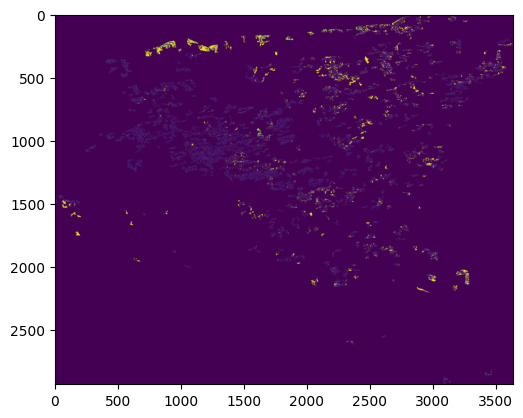

<Axes: >

In [41]:
masked_landcover_data, masked_transform = rasterio.mask.mask(src, [gdf.to_crs(4326).unary_union], crop=True)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [42]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)

#### Cropland

In [43]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [44]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(
    cropland_shapes_gdf, gdf, how="intersection"
)
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(by="Khasra ID").reset_index()

In [45]:
cropland_overlap_gdf["Unavailable Area - Cropland (ha)"] = cropland_overlap_gdf.area / 10_000
cropland_unusable_area_df = cropland_overlap_gdf[["Khasra ID", "Unavailable Area - Cropland (ha)"]]

#### Water

In [46]:
water_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Open surface water",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [47]:
# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(
    water_shapes_gdf, gdf, how="intersection"
)
water_overlap_gdf = water_overlap_gdf.dissolve(by="Khasra ID").reset_index()

In [48]:
water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[["Khasra ID", "Unusable Area - Water (ha)"]]

#### Trees (not used right now)

In [52]:
tree_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Tree cover",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [53]:
# get cutout of the tree shapes that overlap parcels
tree_overlap_gdf = gpd.overlay(
    tree_shapes_gdf, gdf, how="intersection"
)
tree_overlap_gdf = tree_overlap_gdf.dissolve(by="Khasra ID").reset_index()

<Axes: >

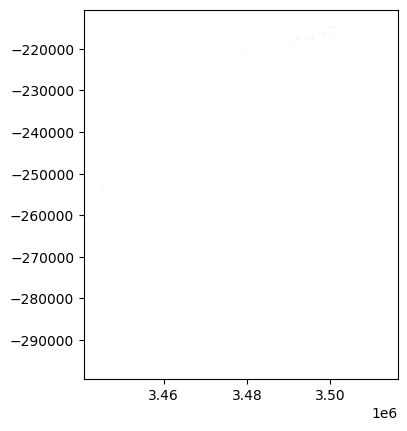

In [54]:
tree_overlap_gdf.plot()

In [55]:
tree_overlap_gdf["Unusable Area - Tree Cover (ha)"] = tree_overlap_gdf.area / 10_000
tree_unusable_area_df = tree_overlap_gdf[["Khasra ID", "Unusable Area - Tree Cover (ha)"]]
tree_unusable_area_df

,Khasra ID,Unusable Area - Tree Cover (ha)
0,BWI1115_khasra_56/1,0.052613
1,BWI1301_khasra_252,0.052637
2,BWI1417_khasra_23,0.073851
3,BWI1441_khasra_640,0.051439
4,BWI1743_khasra_302,0.568640
...,...,...
101,BWI4553_khasra_144,1.520314
102,BWI4556_khasra_146_part_2,0.416176
103,BWI4556_khasra_146_part_3,0.025041
104,BWI4556_khasra_2_part_2,0.121667


### Slope

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


When using the `pydem` package, angles are outputted in radians so we have to convert to degrees. Aspect is measured from the x-axis and counter-clockwise, making East 0 and North 90deg.

We choose between 45 and 135 since north is at 90! 0 is east, and rotates counter-clockwise.

https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html

#### Load slope data

In [56]:
from pydem.dem_processing import DEMProcessor

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pydem/dem_processing.py:76: RuntimeWarning: Cython functions are not compiled. UCA cannot be calculated. Consider compiling cython functions using: python setup.py build_ext --inplace
  warnings.warn("Cython functions are not compiled. UCA cannot be calculated."


In [57]:
def get_steep_shapes(dem_filename, plot=True):
    print(f"Processing {dem_filename}...")
    dem_filepath = RAW_DATA_DIR / "elevation" / f"{dem_filename}.tif"
    dem_proc = DEMProcessor(dem_filepath)
    transform = dem_proc.transform  # need this transform later

    try:
        print("Trying to load pre-calculated slopes and aspects...")
        slope_pydem = np.load(
            RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy"
        )
        aspect_pydem = np.load(
            RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy"
        )
    except FileNotFoundError:
        print("Pre-calculated file not found. Calculating slopes and aspects...")
        slope_pydem, aspect_pydem = dem_proc.calc_slopes_directions()
        np.save(
            RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy", slope_pydem
        )
        np.save(RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy", aspect_pydem)
    # convert from radians to degrees
    aspect = np.degrees(aspect_pydem)
    slope = np.degrees(slope_pydem)

    # set all values below 0 to 0
    aspect[aspect < 0] = 0
    slope[slope < 0] = 0

    # filter to only aspects that are between NE and NW azimuth around north and 7 degrees or more
    slope_mask = np.where((aspect >= 45) & (aspect < 135) & (slope > 7), True, False)

    # Extract vector shapes and make a GeoDataFrame
    print("Extracting vector shapes...")
    vector_shapes = [
        {"geometry": shape(geom)}
        for geom, class_value in shapes(slope, mask=slope_mask, transform=transform)
    ]
    slope_shapes_gdf = gpd.GeoDataFrame(vector_shapes)
    slope_shapes_gdf = slope_shapes_gdf.set_crs(4326).to_crs(INDIA_PROJECTED_CRS)

    if plot:
        # Display slope and aspect
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 6))
        # slope vis
        ax1.imshow(slope)
        ax1.set_title(f"{dem_filename} - Slope")
        ax2.hist(slope.flatten(), bins=100)
        ax2.set_title("Slope Histogram")
        # aspect vis
        ax3.imshow(aspect)
        ax3.set_title(f"{dem_filename} - Aspect")
        ax4.hist(aspect.flatten(), bins=100)
        ax4.set_title("Aspect Histogram")
        plt.tight_layout()
        plt.show()

        # Plot the mask with a binary colormap and correct axes
        x_min = transform[2]
        x_max = x_min + transform[0] * slope_mask.shape[1]
        y_max = transform[5]
        y_min = y_max + transform[4] * slope_mask.shape[0]
        plt.imshow(slope_mask, extent=[x_min, x_max, y_min, y_max], cmap="binary")
        plt.colorbar(label="Aspect Mask", ax=ax)
        plt.title("Aspect Mask")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()

    return slope_shapes_gdf

In [58]:
# input the bounds below in the website and download all tiles that overlap it
gdf_4326.total_bounds

array([74.52937788, 21.38924295, 75.43785863, 22.12235078])

Processing P5_PAN_CD_N21_000_E074_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...


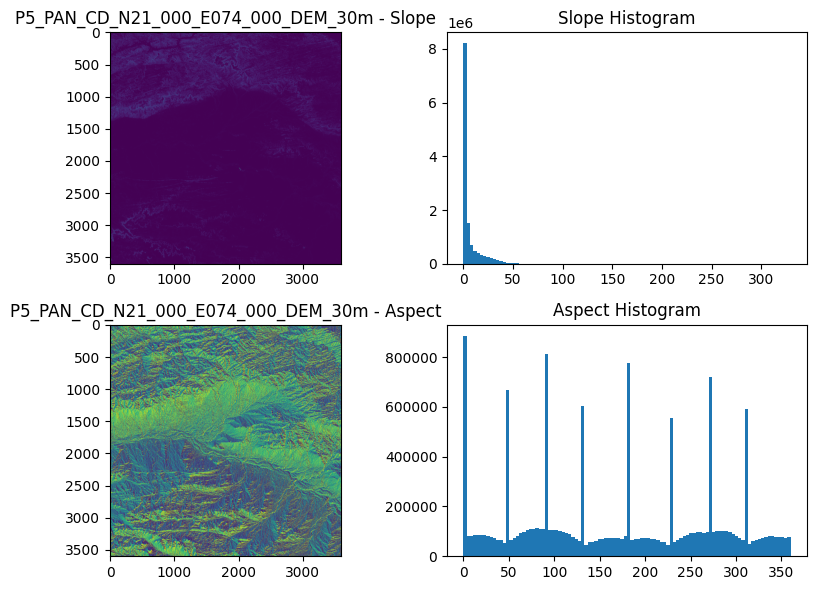

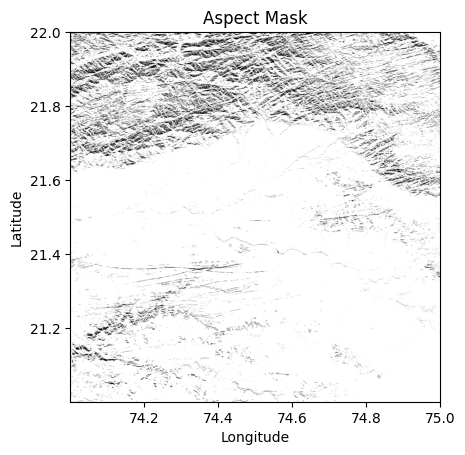

Processing P5_PAN_CD_N21_000_E075_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...


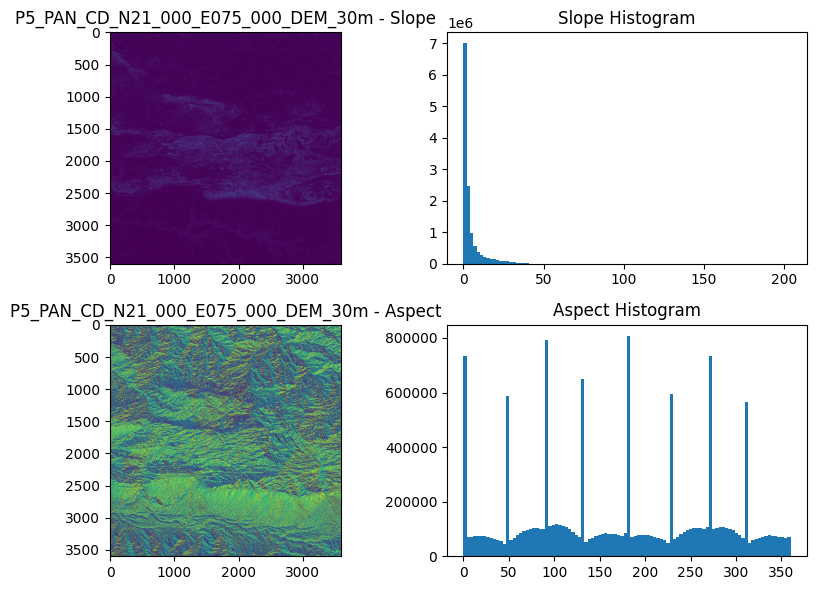

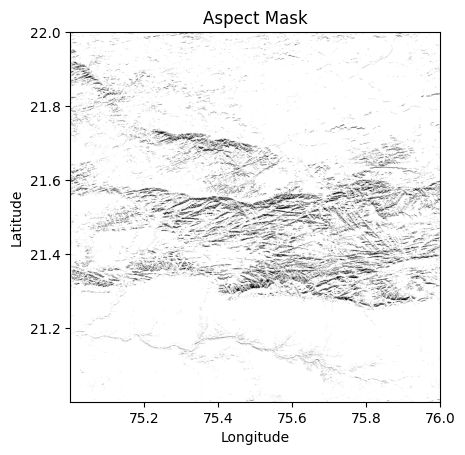

Processing P5_PAN_CD_N22_000_E074_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...


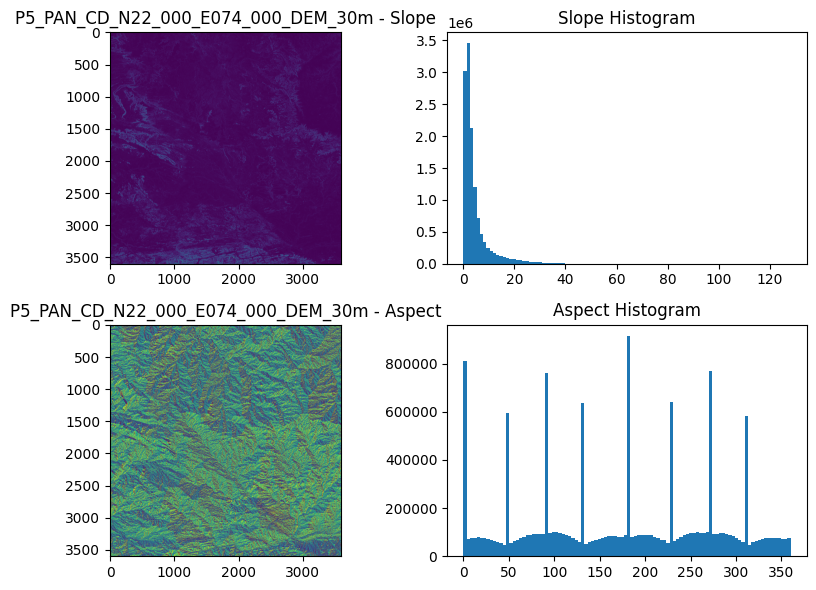

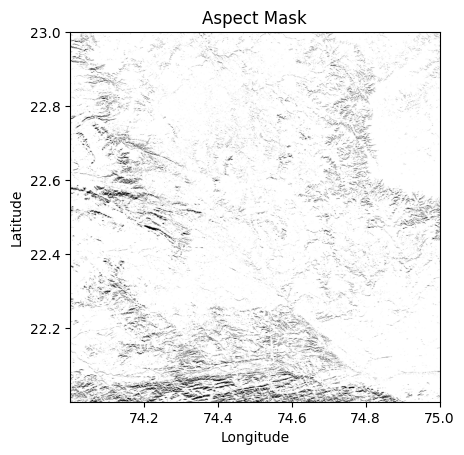

Processing P5_PAN_CD_N22_000_E075_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...


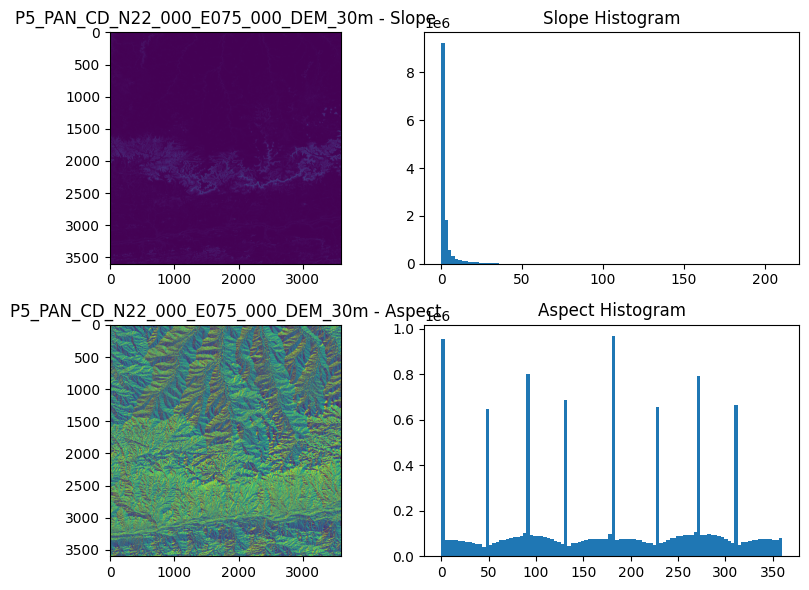

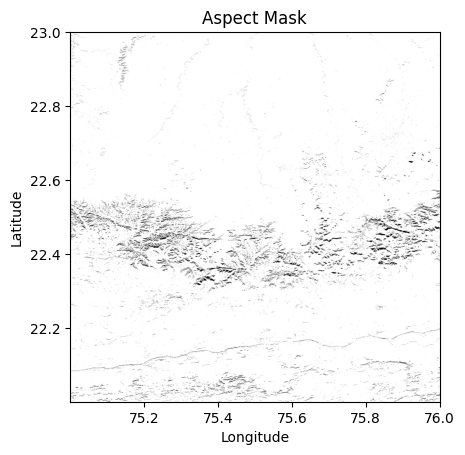

In [59]:
try:
    print("Checking for existing slope overlaps...")
    slope_overlap_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Slopes" / "slopes.parquet"
    )
except FileNotFoundError:
    print("No saved slope overlaps found, processing raw data...")
    dem_filenames = [
        "P5_PAN_CD_N21_000_E074_000_DEM_30m",
        "P5_PAN_CD_N21_000_E075_000_DEM_30m",
        "P5_PAN_CD_N22_000_E074_000_DEM_30m",
        "P5_PAN_CD_N22_000_E075_000_DEM_30m",
    ]

    steep_shapes_gdf_list = []
    for dem_filename in dem_filenames:
        steep_shapes_gdf = get_steep_shapes(dem_filename, plot=True)
        steep_shapes_gdf_list.append(steep_shapes_gdf)

    slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)

    slope_overlap_gdf = gpd.overlay(
        slope_shapes_gdf, gdf, how="intersection", keep_geom_type=False
    )
    slope_overlap_gdf = slope_overlap_gdf.dissolve(by="Khasra ID").reset_index()

    save_shapefiles(
        slope_overlap_gdf,
        PROCESSED_DATA_DIR / "Filtered Slopes",
        "slopes",
        formats=["parquet"],
    )

<Axes: >

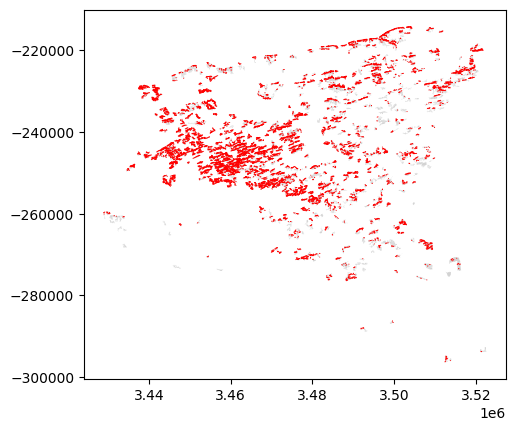

In [60]:
ax = gdf.plot(color="lightgrey")
slope_overlap_gdf.buffer(100).plot(ax=ax, color="red")

In [61]:
slope_overlap_gdf["Unavailable Area - Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[["Khasra ID", "Unavailable Area - Slope (ha)"]]

## Merge in unusable layers
to find out which should be discarded and which taken forward

In [62]:
parcel_gdf_for_unusable_area = gdf.copy()
selected_Name_list = parcel_gdf_for_unusable_area["Khasra ID"].unique()
selected_foldername = "Layered"

#### Plots

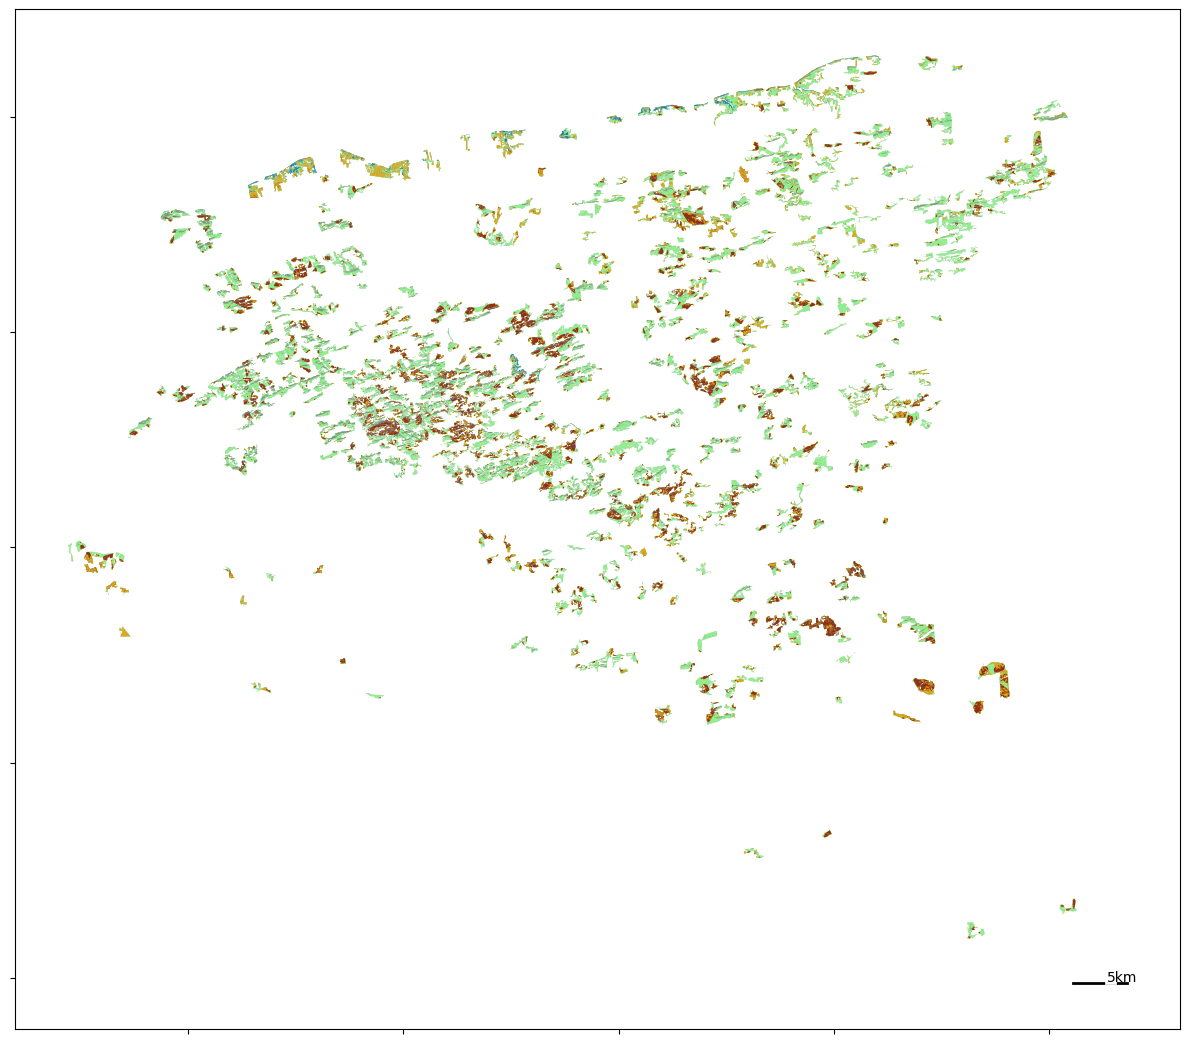

In [63]:
# add colored outline based on Name

ax = gdf.plot(figsize=(12, 12), color="black", alpha=0.2)
parcel_gdf_for_unusable_area.plot(
    ax=ax,
    color=BACKGROUND_COLOR,
    label="Original Khasras",
)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.plot(
    [xmax - 1600, xmax - 1400],
    [ymin + 250, ymin + 250],
    color="white",
    linewidth=7,
    linestyle="-",
)
ax.text(xmax - 500, ymin + 150, "5km", fontsize=10, ha="center")

buildings_overlap_gdf[
    buildings_overlap_gdf["Khasra ID"].isin(selected_Name_list)
].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")

settlements_overlap_gdf[
    settlements_overlap_gdf["Khasra ID"].isin(selected_Name_list)
].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")

water_overlap_gdf[water_overlap_gdf["Khasra ID"].isin(selected_Name_list)].plot(
    ax=ax, color=WATER_COLOR, label="Water"
)

cropland_overlap_gdf[
    cropland_overlap_gdf["Khasra ID"].isin(selected_Name_list)
].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")

slope_overlap_gdf[slope_overlap_gdf["Khasra ID"].isin(selected_Name_list)].plot(
    ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg"
)

plt.tight_layout()
LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras_w_layers.png",
    dpi=300,
    bbox_inches="tight",
)

In [64]:
# ### THIS HAS THE MOST UPDATED PLOTTING CODE - 2nd April 2025
# import matplotlib.patches as mpatches

# for CHOSEN_PARCEL_ID in selected_Name_list:
#     FOLDERPATH = (
#         OUTPUT_DATA_DIR
#         / "Individual Parcels"
#         / selected_foldername
#         / CHOSEN_PARCEL_ID
#     )
#     FOLDERPATH.mkdir(parents=True, exist_ok=True)

#     # # 1. Histogram of intra-distances
#     # subset_intra_distances_df = intra_distances_df[
#     #     intra_distances_df["Khasra ID"] == CHOSEN_PARCEL_ID
#     # ]

#     # f, ax = plt.subplots(1, 1, figsize=(8, 6))
#     # subset_intra_distances_df["raw_distances"].hist(
#     #     ax=ax, bins=25, color="skyblue", edgecolor="black"
#     # )

#     # # add lines for average and 75% percentile
#     # avg_distance = subset_intra_distances_df[
#     #     "Inter-Khasra Distance Average (m)"
#     # ].values[0]
#     # percentile_75th_distance = subset_intra_distances_df[
#     #     "Inter-Khasra Distance 75th Percentile (m)"
#     # ].values[0]

#     # ax.axvline(
#     #     avg_distance,
#     #     color=BACKGROUND_COLOR,
#     #     linestyle="--",
#     #     label=f"Average: {avg_distance}m",
#     # )
#     # ax.axvline(
#     #     percentile_75th_distance,
#     #     color="darkgreen",
#     #     linestyle="--",
#     #     label=f"75th Percentile: {percentile_75th_distance}m",
#     # )

#     # ax.legend()
#     # # ax.set_title(f"Inter-Khasra Distances within {CHOSEN_PARCEL_ID}", fontsize=14)
#     # ax.set_xlabel("Distance to Neighbouring Khasra", fontsize=12)
#     # ax.set_ylabel("Frequency", fontsize=12)
#     # ax.grid(True, linestyle="--", alpha=0.7)

#     # plt.tight_layout()
#     # plt.savefig(
#     #     FOLDERPATH / "intra_distances_histogram.png", dpi=300, bbox_inches="tight"
#     # )
#     # plt.show()

#     # 2. Khasra-level plot
#     ax = gdf[gdf["Khasra ID"] == CHOSEN_PARCEL_ID].plot(
#         column="khasra_id",
#         cmap=ListedColormap(
#             generate_colormap(len(gdf["khasra_id"].unique()))
#         ),
#         figsize=(8, 8),
#     )

#     ax.set_xticklabels([])
#     ax.set_yticklabels([])

#     # add a 1km line to show scale on the plot
#     xmin, xmax = ax.get_xlim()
#     ymin, ymax = ax.get_ylim()
#     ax.plot(
#         [xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-"
#     )
#     ax.plot(
#         [xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-"
#     )
#     ax.plot(
#         [xmax - 550, xmax - 450],
#         [ymin + 50, ymin + 50],
#         color="white",
#         linewidth=7,
#         linestyle="-",
#     )
#     ax.text(xmax - 500, ymin + 50, "1km", fontsize=6, ha="center")

#     plt.tight_layout()
#     plt.savefig(FOLDERPATH / "khasras.png", dpi=300, bbox_inches="tight")

#     # 3. Parcel + Layers plots

#     handles = []
#     for i in range(5):
#         ax = gdf[
#             gdf["Khasra ID"] == CHOSEN_PARCEL_ID
#         ].plot(
#             color=BACKGROUND_COLOR,
#             label="Original Parcel",
#             figsize=(11, 11),
#         )
#         handles.append(
#             mpatches.Patch(
#                 color=BACKGROUND_COLOR,
#                 label="Usable and Available Area",
#             )
#         )
#         ax.set_xticklabels([])
#         ax.set_yticklabels([])
#         ax.set_title(f"{CHOSEN_PARCEL_ID}", fontsize=24)
#         # add a 1km line to show scale on the plot
#         xmin, xmax = ax.get_xlim()
#         ymin, ymax = ax.get_ylim()
#         ax.plot(
#             [xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-"
#         )
#         ax.plot(
#             [xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-"
#         )
#         ax.plot(
#             [xmax - 550, xmax - 450],
#             [ymin + 30, ymin + 30],
#             color="white",
#             linewidth=7,
#             linestyle="-",
#         )
#         ax.text(xmax - 500, ymin + 30, "1km", fontsize=12, ha="center")

#         # add buildings as first layer
#         buildings_overlap_gdf[
#             buildings_overlap_gdf["Khasra ID"] == CHOSEN_PARCEL_ID
#         ].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")
#         LAYERS = "Buildings"
#         handles.append(
#             mpatches.Patch(color=BUILDING_COLOR, label="Buildings + 25m buffer")
#         )

#         if i >= 1:
#             settlements_overlap_gdf[
#                 settlements_overlap_gdf["Khasra ID"] == CHOSEN_PARCEL_ID
#             ].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")
#             LAYERS = "Buildings, Settlements"
#             handles.append(mpatches.Patch(color=SETTLEMENT_COLOR, label="Settlements"))

#         if i >= 2:
#             water_overlap_gdf[water_overlap_gdf["Khasra ID"] == CHOSEN_PARCEL_ID].plot(
#                 ax=ax, color=WATER_COLOR, label="Water"
#             )
#             LAYERS = "Buildings, Settlements, Water"
#             handles.append(mpatches.Patch(color=WATER_COLOR, label="Water"))

#         if i >= 3:
#             cropland_overlap_gdf[
#                 cropland_overlap_gdf["Khasra ID"] == CHOSEN_PARCEL_ID
#             ].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")
#             LAYERS = "Buildings, Settlements, Water, Cropland"
#             handles.append(mpatches.Patch(color=CROPLAND_COLOR, label="Cropland"))

#         if i >= 4:
#             slope_overlap_gdf[slope_overlap_gdf["Khasra ID"] == CHOSEN_PARCEL_ID].plot(
#                 ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg"
#             )
#             LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
#             handles.append(
#                 mpatches.Patch(color=SLOPE_COLOR, label="Slope > 7° between NE and NW")
#             )

#         ax.legend(handles=handles, loc="upper left")
#         plt.tight_layout()
#         plt.savefig(
#             FOLDERPATH / f"Layers - {LAYERS}.png", dpi=300, bbox_inches="tight"
#         )
#         handles = []

#### Calculate Areas

##### Cut out unusable

In [65]:
parcel_gdf_for_unusable_area["Original Area (ha)"] = parcel_gdf_for_unusable_area["geometry"].area / 10000

In [66]:
output_parcel_gdf = parcel_gdf_for_unusable_area.copy()

# cut out water
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    water_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out settlements
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    settlements_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

In [67]:
output_parcel_gdf = clean_geometry(output_parcel_gdf)

In [68]:
# make usable area var so we can put unusable columns first, then usable ones
usable_area_series = output_parcel_gdf.area / 10_000
# unusable area
output_parcel_gdf["Unusable Area (ha)"] = (
    output_parcel_gdf["Original Area (ha)"] - usable_area_series
)
# usable area
output_parcel_gdf["Usable Area (ha)"] = usable_area_series

In [69]:
output_parcel_gdf

,Khasra ID,Khasra Name,Patch Name,geometry,Original Area (ha),Unusable Area (ha),Usable Area (ha)
0,BWI20_khasra_61,61,BWI20,"POLYGON ((3513988.388 -295847.592, 3513991.126...",9.672750,0.000000,9.672750
1,BWI20_khasra_62,62,BWI20,"POLYGON ((3513988.388 -295847.592, 3513978.258...",5.369846,0.000000,5.369846
2,BWI20_khasra_57,57,BWI20,"MULTIPOLYGON (((3513605.761 -295700.399, 35136...",7.090892,1.542347,5.548546
3,BWI32_khasra_50,50,BWI32,"POLYGON ((3512953.177 -296233.160, 3513078.837...",4.060142,0.000000,4.060142
4,BWI32_khasra_48,48,BWI32,"POLYGON ((3512904.531 -296062.410, 3512900.696...",4.934054,0.000000,4.934054
...,...,...,...,...,...,...,...
13415,BWI3935_khasra_79/2_part_4,79/2,BWI3935,"POLYGON ((3471502.486 -228108.900, 3471502.763...",0.028143,0.000000,0.028143
13416,BWI3935_khasra_38_part_4,38,BWI3935,"POLYGON ((3471502.486 -228108.900, 3471502.763...",0.028143,0.000000,0.028143
13417,BWI3983_khasra_162_part_10,162,BWI3983,"POLYGON ((3485136.175 -228669.351, 3485135.086...",0.066700,0.000000,0.066700
13418,BWI3983_khasra_120_part_5,120,BWI3983,"POLYGON ((3485136.175 -228669.351, 3485135.086...",0.066700,0.000000,0.066700


In [70]:
save_shapefiles(
    output_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable",
    formats=["parquet", "kml", "csv"],
)

##### Cut out unavailable

In [71]:
# cut out cropland
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    cropland_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

# cut out rogue buildings
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    rogue_buildings_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

# cut out slopes
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    slope_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

In [72]:
output_parcel_gdf["Usable and Available Area (ha)"] = output_parcel_gdf.area / 10_000
output_parcel_gdf["Usable but Unavailable Area (ha)"] = (
    output_parcel_gdf["Usable Area (ha)"]
    - output_parcel_gdf["Usable and Available Area (ha)"]
)

In [73]:
# percentages
output_parcel_gdf["Unusable Area (%)"] = (
    output_parcel_gdf["Unusable Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)
output_parcel_gdf["Usable Area (%)"] = (
    output_parcel_gdf["Usable Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)
output_parcel_gdf["Usable and Available Area (%)"] = (
    output_parcel_gdf["Usable and Available Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)
output_parcel_gdf["Usable but Unavailable Area (%)"] = (
    output_parcel_gdf["Usable but Unavailable Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)

In [74]:
# add unusable areas
all_unusable_area_cols_df = settlements_unusable_area_df.merge(rogue_buildings_unusable_area_df, on="Khasra ID", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(water_unusable_area_df, on="Khasra ID", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(cropland_unusable_area_df, on="Khasra ID", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(slope_unusable_area_df, on="Khasra ID", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(building_counts_df, on="Khasra ID", how="outer").fillna(0)
output_parcel_gdf = output_parcel_gdf.merge(all_unusable_area_cols_df, on="Khasra ID", how="left").fillna(0)

In [75]:
output_parcel_gdf.fillna(0, inplace=True)

In [76]:
save_shapefiles(
    output_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable_available",
    formats=["parquet", "kml", "csv"],
)

### Save per-patch statistics

In [77]:
patch_level_stats_df = (
    output_parcel_gdf.drop(
        columns=[
            "Khasra Name",
            "Khasra ID",
            "Unusable Area (%)",
            "Usable Area (%)",
            "Usable and Available Area (%)",
            "Usable but Unavailable Area (%)",
            "geometry",
        ]
    )
    .groupby("Patch Name")
    .sum()
    .round(2)
)
# make two columns, one count, one list of all names that fall inside this parcel. list should just be formatted as a long string
count_filtered_parcel_gdf = output_parcel_gdf.groupby("Patch Name").agg(
    khasra_count=("Khasra ID", "size"),
    khasra_names=("Khasra ID", lambda x: ", ".join(list(x))),
)
count_filtered_parcel_gdf.rename(
    columns={"khasra_count": "Khasra Count", "khasra_names": "Khasra IDs"},
    inplace=True,
)
# combine
patch_level_stats_df = patch_level_stats_df.merge(
    count_filtered_parcel_gdf, on="Patch Name"
)

In [78]:
# calculate % columns again

patch_level_stats_df["Unusable Area (%)"] = (
    patch_level_stats_df["Unusable Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
patch_level_stats_df["Usable Area (%)"] = (
    patch_level_stats_df["Usable Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
patch_level_stats_df["Usable and Available Area (%)"] = (
    patch_level_stats_df["Usable and Available Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
patch_level_stats_df["Usable but Unavailable Area (%)"] = (
    patch_level_stats_df["Usable but Unavailable Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)

In [79]:
patch_level_stats_df = patch_level_stats_df[
    [
        "Original Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (ha)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Unusable Area (%)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Unusable Area - Water (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Slope (ha)",
        "Building Count",
        "Khasra Count",
        "Khasra IDs",
    ]
]

In [80]:
patch_level_stats_df

,Original Area (ha),Unusable Area (ha),Usable Area (ha),Usable and Available Area (ha),Usable but Unavailable Area (ha),Unusable Area (%),Usable Area (%),Usable and Available Area (%),Usable but Unavailable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unavailable Area - Slope (ha),Building Count,Khasra Count,Khasra IDs
Patch Name,,,,,,,,,,,,,,,,,
BWI1004,53.57,10.32,43.25,35.59,7.67,19.26,80.74,66.44,14.32,10.32,0.00,0.0,2.17,5.57,55.0,49,"BWI1004_khasra_24/1, BWI1004_khasra_121/1_part..."
BWI1019,31.85,8.56,23.29,20.95,2.34,26.88,73.12,65.78,7.35,8.56,0.00,0.0,1.02,1.81,36.0,12,"BWI1019_khasra_186, BWI1019_khasra_170_part_2,..."
BWI1035,23.22,1.18,22.04,20.29,1.75,5.08,94.92,87.38,7.54,1.18,0.00,0.0,0.00,1.75,11.0,7,"BWI1035_khasra_128, BWI1035_khasra_123, BWI103..."
BWI1044,30.31,12.54,17.77,2.99,14.78,41.37,58.63,9.86,48.76,12.54,0.00,0.0,26.77,0.00,25.0,1,BWI1044_khasra_403
BWI1051,32.21,20.00,12.21,2.77,9.44,62.09,37.91,8.60,29.31,20.00,0.00,0.0,28.26,0.00,97.0,13,"BWI1051_khasra_207/1, BWI1051_khasra_196, BWI1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BWI972,24.50,10.41,14.09,11.03,3.06,42.49,57.51,45.02,12.49,10.41,0.00,0.0,3.85,1.00,47.0,7,"BWI972_khasra_209, BWI972_khasra_207, BWI972_k..."
BWI984,20.91,11.50,9.41,1.09,8.32,55.00,45.00,5.21,39.79,11.50,0.00,0.0,18.96,0.00,22.0,15,"BWI984_khasra_8, BWI984_khasra_63/1_part_1, BW..."
BWI989,42.73,8.20,34.53,25.84,8.69,19.19,80.81,60.47,20.34,8.20,0.03,0.0,9.48,2.10,49.0,8,"BWI989_khasra_270/2, BWI989_khasra_272, BWI989..."


In [81]:
patch_level_stats_df.to_csv(
    OUTPUT_DATA_DIR / "patch_stats.csv"
)

## Save individual layers

In [82]:
# save all unusable layes as separate KML files

# cropland
save_shapefiles(
    cropland_overlap_gdf.loc[
        cropland_overlap_gdf["Khasra ID"].isin(selected_Name_list),
        [
            "Khasra ID",
            "geometry",
            "Unavailable Area - Cropland (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "cropland",
    formats=["kml"],
)


# water
save_shapefiles(
    water_overlap_gdf.loc[
        water_overlap_gdf["Khasra ID"].isin(selected_Name_list),
        [
            "Khasra ID",
            "geometry",
            "Unusable Area - Water (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "water",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf.loc[
        settlements_overlap_gdf["Khasra ID"].isin(selected_Name_list),
        [
            "Khasra ID",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "settlements",
    formats=["kml"],
)

# rogue buildings
save_shapefiles(
    rogue_buildings_overlap_gdf.loc[
        rogue_buildings_overlap_gdf["Khasra ID"].isin(selected_Name_list),
        [
            "Khasra ID",
            "geometry",
            "Unavailable Area - Isolated Buildings (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "rogue_buildings",
    formats=["kml"],
)

# slopes
save_shapefiles(
    slope_overlap_gdf.loc[
        slope_overlap_gdf["Khasra ID"].isin(selected_Name_list),
        [
            "Khasra ID",
            "geometry",
            "Unavailable Area - Slope (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "slopes",
    formats=["kml"],
)

### get roads

In [83]:
# import osmnx as ox

In [84]:
# def get_osm_roads(
#     query: str, network_type: str = "drive", plot: bool = False
# ) -> gpd.GeoDataFrame:

#     # get OSM data graph
#     streets_graph = ox.graph_from_place(query, network_type=network_type)
#     streets_graph = ox.projection.project_graph(streets_graph)

#     # convert to GeoDataFrame
#     roads_gdf = ox.graph_to_gdfs(
#         ox.convert.to_undirected(streets_graph),
#         nodes=False,
#         edges=True,
#         node_geometry=False,
#         fill_edge_geometry=True,
#     )

#     if plot:
#         roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()
#     return roads_gdf.reset_index()



# def get_osm_roads_from_bbox(
#     bbox, network_type: str = "drive", plot: bool = False
# ) -> gpd.GeoDataFrame:

#     # get OSM data graph
#     streets_graph = ox.graph.graph_from_bbox(bbox=bbox, network_type=network_type)
#     streets_graph = ox.projection.project_graph(streets_graph)

#     # convert to GeoDataFrame
#     roads_gdf = ox.graph_to_gdfs(
#         ox.convert.to_undirected(streets_graph),
#         nodes=False,
#         edges=True,
#         node_geometry=False,
#         fill_edge_geometry=True,
#     )

#     if plot:
#         roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()
#     return roads_gdf.reset_index()



# def get_osm_roads_from_point(
#     point, dist, network_type: str = "drive", plot: bool = False
# ) -> gpd.GeoDataFrame:

#     # get OSM data graph
#     streets_graph = ox.graph.graph_from_point(point, dist=dist, dist_type="bbox", network_type=network_type)
#     streets_graph = ox.projection.project_graph(streets_graph)

#     # convert to GeoDataFrame
#     roads_gdf = ox.graph_to_gdfs(
#         ox.convert.to_undirected(streets_graph),
#         nodes=False,
#         edges=True,
#         node_geometry=False,
#         fill_edge_geometry=True,
#     )

#     if plot:
#         roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()
#     return roads_gdf.reset_index()

In [85]:
# lat1, lon1 = 26.019683, 77.558542
# roads_gdf_lower = get_osm_roads_from_point((lat1, lon1), dist=45000, network_type="drive")


# lat2, lon2 = 26.449800, 77.777881
# roads_gdf_upper = get_osm_roads_from_point((lat2, lon2), dist=15000, network_type="drive")

# roads_gdf = pd.concat([roads_gdf_lower, roads_gdf_upper])
# roads_gdf.drop_duplicates(subset=["u", "v"], inplace=True)
# roads_gdf = roads_gdf.to_crs(INDIA_PROJECTED_CRS)

In [86]:
# ax=roads_gdf.plot()
# output_parcel_gdf.plot(ax=ax, facecolor="none", edgecolor="red")

In [87]:
# save_shapefiles(
#     roads_gdf.to_crs(epsg=4326),
#     PROCESSED_DATA_DIR / "Filtered Roads",
#     "roads",
#     formats=["kml"],
# )

## Cluster and get stats

In [88]:
import shapely

In [ ]:
suggested_parcels_gdf = gpd.read_file(OUTPUT_DATA_DIR / "Morena" / "Suggested Parcels.kml").to_crs(epsg=INDIA_PROJECTED_CRS)
suggested_parcels_gdf.geometry = suggested_parcels_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
suggested_parcels_gdf.drop(columns=["Description"], inplace=True)
suggested_parcels_gdf.rename(columns={"Name": "Parcel Name"}, inplace=True)

In [ ]:
filtered_parcel_gdf = output_parcel_gdf.sjoin(suggested_parcels_gdf, predicate="within").drop(columns=["index_right"])
filtered_parcel_gdf

In [ ]:
parcel_level_stats_df = (
    filtered_parcel_gdf.drop(
        columns=[
            "Khasra Name",
            "Patch Name",
            "Khasra ID",
            "Description",
            "source",
            "Unusable Area (%)",
            "Usable Area (%)",
            "Usable and Available Area (%)",
            "Usable but Unavailable Area (%)",
            "geometry",
        ]
    )
    .groupby("Parcel Name")
    .sum()
    .round(2)
)

In [ ]:
# make two columns, one count, one list of all names that fall inside this parcel. list should just be formatted as a long string
count_filtered_parcel_gdf = filtered_parcel_gdf.groupby("Parcel Name").agg(
    khasra_count=("Khasra ID", "size"),
    khasra_names=("Khasra ID", lambda x: ", ".join(list(x)))
)
count_filtered_parcel_gdf.rename(
    columns={"khasra_count": "Khasra Count", "khasra_names": "Khasra IDs"},
    inplace=True,
)

In [ ]:
# combine
parcel_level_stats_df = parcel_level_stats_df.merge(count_filtered_parcel_gdf, on="Parcel Name")

In [ ]:
parcel_level_stats_df

In [ ]:
# calculate % columns again

parcel_level_stats_df["Unusable Area (%)"] = (
    parcel_level_stats_df["Unusable Area (ha)"]
    / parcel_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
parcel_level_stats_df["Usable Area (%)"] = (
    parcel_level_stats_df["Usable Area (ha)"]
    / parcel_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
parcel_level_stats_df["Usable and Available Area (%)"] = (
    parcel_level_stats_df["Usable and Available Area (ha)"]
    / parcel_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
parcel_level_stats_df["Usable but Unavailable Area (%)"] = (
    parcel_level_stats_df["Usable but Unavailable Area (ha)"]
    / parcel_level_stats_df["Original Area (ha)"]
    * 100
).round(2)

In [ ]:
parcel_level_stats_df = parcel_level_stats_df[
    [
        "Original Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (ha)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Unusable Area (%)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Unusable Area - Water (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Slope (ha)",
        "Building Count",
        "Khasra Count",
        "Khasra IDs",
    ]
]

In [ ]:
parcel_level_stats_df.to_csv(
    OUTPUT_DATA_DIR / "suggested_parcels_stats.csv"
)